# Introduction

Since Jan. 1, 2015, [The Washington Post](https://www.washingtonpost.com/) has been compiling a database of every fatal shooting in the US by a police officer in the line of duty.

<center><img src=https://i.imgur.com/sX3K62b.png></center>

While there are many challenges regarding data collection and reporting, The Washington Post has been tracking more than a dozen details about each killing. This includes the race, age and gender of the deceased, whether the person was armed, and whether the victim was experiencing a mental-health crisis. The Washington Post has gathered this supplemental information from law enforcement websites, local new reports, social media, and by monitoring independent databases such as "Killed by police" and "Fatal Encounters". The Post has also conducted additional reporting in many cases.

There are 4 additional datasets: US census data on poverty rate, high school graduation rate, median household income, and racial demographics. [Source of census data](https://factfinder.census.gov/faces/nav/jsf/pages/community_facts.xhtml).

### Upgrade Plotly

Run the cell below if you are working with Google Colab

In [1]:
%pip install --upgrade plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 28.4 MB/s eta 0:00:00
  Attempting uninstall: plotly
    Found existing installation: plotly 5.24.1
    Uninstalling plotly-5.24.1:
      Successfully uninstalled plotly-5.24.1


## Import Statements

In [2]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# This might be helpful:
from collections import Counter

## Notebook Presentation

In [3]:
pd.options.display.float_format = '{:,.2f}'.format

## Load the Data

In [4]:
df_hh_income = pd.read_csv('Median_Household_Income_2015.csv', encoding="windows-1252")
df_pct_poverty = pd.read_csv('Pct_People_Below_Poverty_Level.csv', encoding="windows-1252")
df_pct_completed_hs = pd.read_csv('Pct_Over_25_Completed_High_School.csv', encoding="windows-1252")
df_share_race_city = pd.read_csv('Share_of_Race_By_City.csv', encoding="windows-1252")
df_fatalities = pd.read_csv('Deaths_by_Police_US.csv', encoding="windows-1252")

# Preliminary Data Exploration

* What is the shape of the DataFrames?
* How many rows and columns do they have?
* What are the column names?
* Are there any NaN values or duplicates?

In [5]:
print(df_hh_income.info())
print(df_hh_income.describe())
print(f'★★★df_hh_income na:\n{df_hh_income.isna().sum()}')
print(f'★★★df_hh_income dup:{df_hh_income.duplicated().sum()}')
print(df_hh_income.head())
print(df_hh_income.tail())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29322 entries, 0 to 29321
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Geographic Area  29322 non-null  object
 1   City             29322 non-null  object
 2   Median Income    29271 non-null  object
dtypes: object(3)
memory usage: 687.4+ KB
None
       Geographic Area           City Median Income
count            29322          29322         29271
unique              51          24249         14592
top                 PA  Franklin city           (X)
freq              1762             16          1113
★★★df_hh_income na:
Geographic Area     0
City                0
Median Income      51
dtype: int64
★★★df_hh_income dup:0
  Geographic Area             City Median Income
0              AL       Abanda CDP         11207
1              AL   Abbeville city         25615
2              AL  Adamsville city         42575
3              AL     Addison town         

In [6]:
# print(df_pct_poverty.info())
# print(df_pct_poverty.describe())
# print(f'★★★df_pct_poverty na:\n{df_pct_poverty.isna().sum()}')
# print(f'★★★2df_pct_poverty dup:{df_pct_poverty.duplicated().sum()}')
# print(df_pct_poverty.head())
# print(df_pct_poverty.tail())
print(df_pct_poverty.sample(5))

      Geographic Area                 City poverty_rate
21686              PA  Briar Creek borough           33
2851               CA    Mountain Mesa CDP         67.1
11891              MI       Edmore village         27.7
20949              OK    Rentiesville town         24.8
23239              PA           Witmer CDP          5.7


In [7]:
print(df_pct_completed_hs.info())
print(df_pct_completed_hs.describe())
print(f'★★★df_pct_completed_hs na:\n{df_pct_completed_hs.isna().sum()}')
print(f'★★★2df_pct_completed_hs dup:{df_pct_completed_hs.duplicated().sum()}')
print(df_pct_completed_hs.head())
print(df_pct_completed_hs.tail())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29329 entries, 0 to 29328
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Geographic Area       29329 non-null  object
 1   City                  29329 non-null  object
 2   percent_completed_hs  29329 non-null  object
dtypes: object(3)
memory usage: 687.5+ KB
None
       Geographic Area           City percent_completed_hs
count            29329          29329                29329
unique              51          24255                  728
top                 PA  Franklin city                  100
freq              1762             16                 1301
★★★df_pct_completed_hs na:
Geographic Area         0
City                    0
percent_completed_hs    0
dtype: int64
★★★2df_pct_completed_hs dup:0
  Geographic Area             City percent_completed_hs
0              AL       Abanda CDP                 21.2
1              AL   Abbeville city      

In [8]:
print(df_share_race_city.info())
print(df_share_race_city.describe())
print(f'★★★df_share_race_city na:\n{df_share_race_city.isna().sum()}')
print(f'★★★2df_share_race_city dup:{df_share_race_city.duplicated().sum()}')
print(df_share_race_city.head())
print(df_share_race_city.tail())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29268 entries, 0 to 29267
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Geographic area        29268 non-null  object
 1   City                   29268 non-null  object
 2   share_white            29268 non-null  object
 3   share_black            29268 non-null  object
 4   share_native_american  29268 non-null  object
 5   share_asian            29268 non-null  object
 6   share_hispanic         29268 non-null  object
dtypes: object(7)
memory usage: 1.6+ MB
None
       Geographic area           City share_white share_black  \
count            29268          29268       29268       29268   
unique              51          24219         997         926   
top                 PA  Franklin city         100           0   
freq              1764             16        1051        6587   

       share_native_american share_asian share_hispanic  
coun

In [9]:
print(df_fatalities.info())
print(df_fatalities.describe())
print(f'★★★df_fatalities na:\n{df_fatalities.isna().sum()}')
print(f'★★★2df_fatalities dup:{df_fatalities.duplicated().sum()}')
print(df_fatalities.head())
print(df_fatalities.tail())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2535 entries, 0 to 2534
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       2535 non-null   int64  
 1   name                     2535 non-null   object 
 2   date                     2535 non-null   object 
 3   manner_of_death          2535 non-null   object 
 4   armed                    2526 non-null   object 
 5   age                      2458 non-null   float64
 6   gender                   2535 non-null   object 
 7   race                     2340 non-null   object 
 8   city                     2535 non-null   object 
 9   state                    2535 non-null   object 
 10  signs_of_mental_illness  2535 non-null   bool   
 11  threat_level             2535 non-null   object 
 12  flee                     2470 non-null   object 
 13  body_camera              2535 non-null   bool   
dtypes: bool(2), float64(1), 

## Data Cleaning - Check for Missing Values and Duplicates

Consider how to deal with the NaN values. Perhaps substituting 0 is appropriate.

In [10]:
df_hh_income['Median Income'] = pd.to_numeric(df_hh_income['Median Income'], errors='coerce')

df_hh_income['Median Income'] = df_hh_income['Median Income'].fillna(df_hh_income.groupby('Geographic Area')['Median Income'].transform('median'))

df_hh_income.isna().sum()

,0
Geographic Area,0
City,0
Median Income,0


In [11]:
df_fatalities = df_fatalities.dropna(subset=['armed'])

df_fatalities = df_fatalities.fillna({
    'race': 'Unknown',
    'flee': 'Unknown',
    'age': -1,
})

df_fatalities.isna().sum()


,0
id,0
name,0
date,0
manner_of_death,0
armed,0
age,0
gender,0
race,0
city,0
state,0


# Chart the Poverty Rate in each US State

Create a bar chart that ranks the poverty rate from highest to lowest by US state. Which state has the highest poverty rate? Which state has the lowest poverty rate?  Bar Plot

In [4]:
df_pct_poverty['poverty_rate'] = pd.to_numeric(df_pct_poverty['poverty_rate'], errors='coerce')


In [35]:

poverty_by_state = df_pct_poverty.groupby('Geographic Area', as_index=False)['poverty_rate'].median().sort_values(by='poverty_rate',ascending=False)

poverty_by_state_bar = px.bar(data_frame=poverty_by_state, x='Geographic Area',y='poverty_rate',
                              color='poverty_rate',
                              color_continuous_scale='rdgy')

poverty_by_state_bar.update_layout(
    title='Poverty Rate by State',
    xaxis_title='State',
    yaxis_title='Poverty Rate',
)
poverty_by_state_bar.show()


In [13]:
print(f"Which state has the highest poverty rate? {poverty_by_state['Geographic Area'].iloc[0]} - {poverty_by_state['poverty_rate'].iloc[0]}")
print(f"Which state has the lowest poverty rate? {poverty_by_state['Geographic Area'].iloc[-1]} - {poverty_by_state['poverty_rate'].iloc[-1]}")

Which state has the highest poverty rate? MS - 26.45
Which state has the lowest poverty rate? WY - 6.4


# Chart the High School Graduation Rate by US State

Show the High School Graduation Rate in ascending order of US States. Which state has the lowest high school graduation rate? Which state has the highest?

In [5]:
df_pct_completed_hs['percent_completed_hs'] = pd.to_numeric(df_pct_completed_hs['percent_completed_hs'], errors='coerce')


In [34]:
completed_hs_by_state = df_pct_completed_hs.groupby('Geographic Area', as_index=False)['percent_completed_hs'].median().sort_values(by='Geographic Area',ascending=True)

completed_hs_by_state_bar = px.bar(completed_hs_by_state, x='Geographic Area',y='percent_completed_hs',
                              color='percent_completed_hs',
                              color_continuous_scale='darkmint')

completed_hs_by_state_bar.update_layout(
    title='High School Graduation Rate by US State',
    xaxis_title='State',
    yaxis_title='High School Graduation Rate',
)
completed_hs_by_state_bar.show()


In [38]:
completed_hs_by_state_sorted = completed_hs_by_state.sort_values(by='percent_completed_hs',ascending=False)

print(f"Which state has the highest high school graduation rate? {completed_hs_by_state_sorted['Geographic Area'].iloc[0]} - {completed_hs_by_state_sorted['percent_completed_hs'].iloc[0]}")
print(f"Which state has the lowest high school graduation rate? {completed_hs_by_state_sorted['Geographic Area'].iloc[-1]} - {completed_hs_by_state_sorted['percent_completed_hs'].iloc[-1]}")

Which state has the highest high school graduation rate? MA - 93.9
Which state has the lowest high school graduation rate? MS - 78.3


# Visualise the Relationship between Poverty Rates and High School Graduation Rates

#### Create a line chart with two y-axes to show if the rations of poverty and high school graduation move together.  

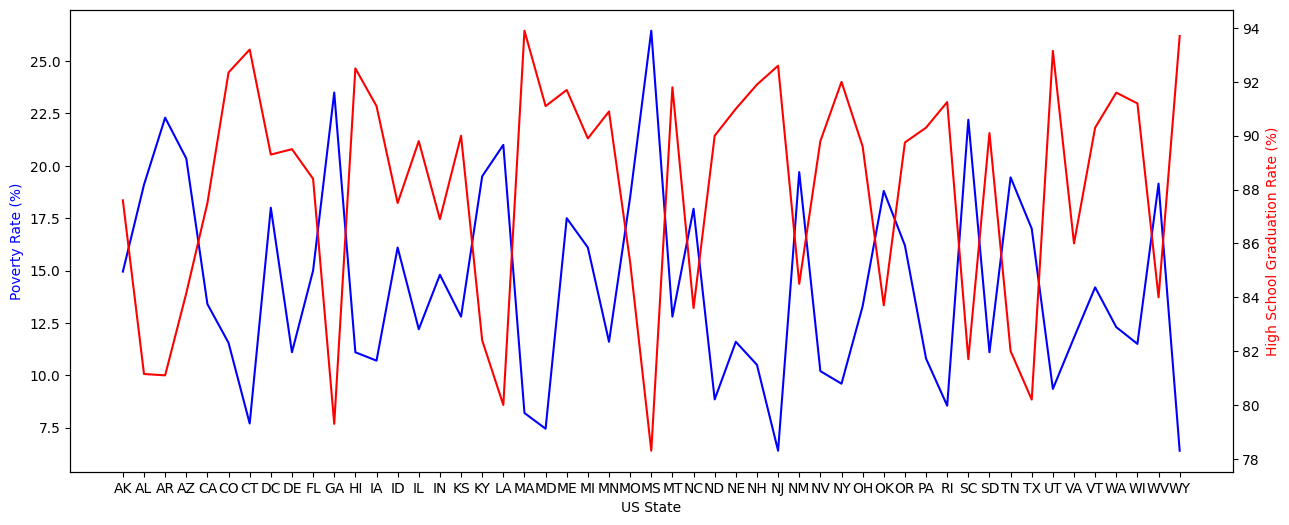

In [46]:
fig, ax1 = plt.subplots(figsize=(15, 6)) # Thêm figsize cho khung tranh rộng rãi, dễ thở
ax2 = ax1.twinx()                  # tạo trục Y phải (dùng chung trục X)

ax1.plot(poverty_by_state_sorted_geo['Geographic Area'], poverty_by_state_sorted_geo['poverty_rate'], color='blue', label='Poverty Rate')
ax2.plot(completed_hs_by_state['Geographic Area'], completed_hs_by_state['percent_completed_hs'], color='red', label='HS Completed Rate')

ax1.set_xlabel('US State')
ax1.set_ylabel('Poverty Rate (%)', color='blue')
ax2.set_ylabel('High School Graduation Rate (%)', color='red')

plt.show()

#### Now use a Seaborn .jointplot() with a Kernel Density Estimate (KDE) and/or scatter plot to visualise the same relationship

In [48]:
pov_hscom_merge = pd.merge(poverty_by_state_sorted_geo, completed_hs_by_state, on='Geographic Area')

df_pov_hscom = pov_hscom_merge[['Geographic Area', 'poverty_rate', 'percent_completed_hs']]
print(df_pov_hscom.head())
print(df_pov_hscom.tail())

  Geographic Area  poverty_rate  percent_completed_hs
0              AK         14.95                 87.60
1              AL         19.10                 81.15
2              AR         22.30                 81.10
3              AZ         20.35                 84.15
4              CA         13.40                 87.50
   Geographic Area  poverty_rate  percent_completed_hs
46              VT         14.20                 90.30
47              WA         12.30                 91.60
48              WI         11.50                 91.20
49              WV         19.15                 84.00
50              WY          6.40                 93.70


Text(0.5, 1.02, 'Poverty VS High School Graduation')

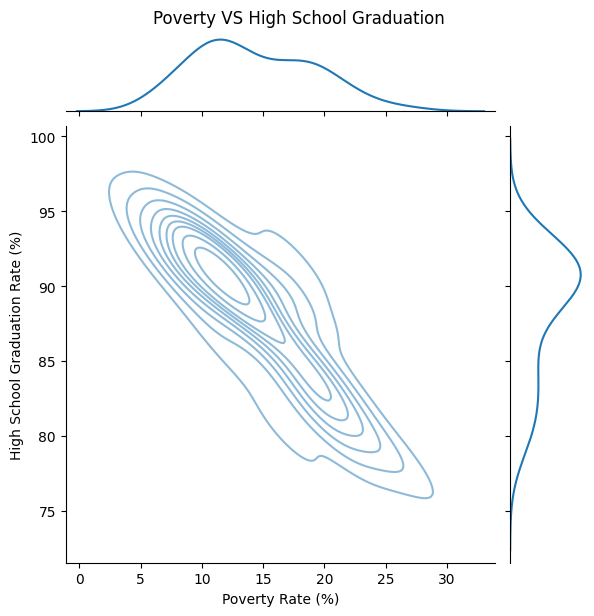

In [58]:
from re import X
poverty_hs_comp_joinp = sns.jointplot(data=df_pov_hscom,
              x='poverty_rate',
              y='percent_completed_hs',
              kind='kde',            # 'hex', 'kde', 'reg'
              joint_kws={'alpha': 0.5})
poverty_hs_comp_joinp.set_axis_labels("Poverty Rate (%)", "High School Graduation Rate (%)")
poverty_hs_comp_joinp.fig.suptitle("Poverty VS High School Graduation", y=1.02)

#### Seaborn's `.lmplot()` or `.regplot()` to show a linear regression between the poverty ratio and the high school graduation ratio.

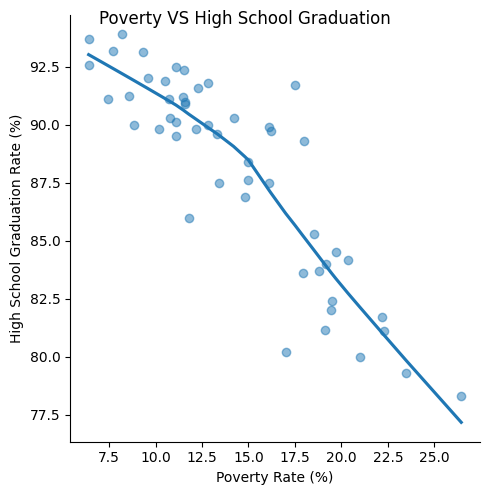

In [72]:
pov_hscom_lmp = sns.lmplot(
    data=df_pov_hscom,
    x='poverty_rate',
    y='percent_completed_hs',
    lowess=True,
    scatter_kws={'alpha': 0.5})

pov_hscom_lmp.set_axis_labels("Poverty Rate (%)", "High School Graduation Rate (%)")
pov_hscom_lmp.fig.suptitle("Poverty VS High School Graduation")

plt.show()

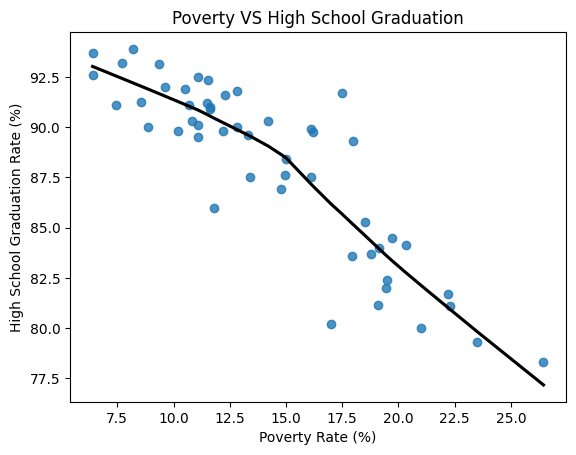

In [73]:
pov_hscom_regp = sns.regplot(data=df_pov_hscom, x='poverty_rate', y='percent_completed_hs',
            lowess=True,              # moving average thay vì linear
            line_kws={'color': 'black'})

pov_hscom_regp.set_xlabel("Poverty Rate (%)")
pov_hscom_regp.set_ylabel("High School Graduation Rate (%)")
pov_hscom_regp.set_title("Poverty VS High School Graduation")

plt.show()

# Create a Bar Chart with Subsections Showing the Racial Makeup of Each US State

Visualise the share of the white, black, hispanic, asian and native american population in each US State using a bar chart with sub sections.

In [76]:
cols_to_convert = ['share_white', 'share_black', 'share_asian', 'share_hispanic', 'share_native_american']

df_share_race_city[cols_to_convert] = df_share_race_city[cols_to_convert].apply(pd.to_numeric, errors='coerce')

In [79]:
share_race_mean = df_share_race_city.groupby('Geographic area')[['share_white', 'share_black', 'share_asian', 'share_hispanic', 'share_native_american']].mean()

share_race_by_state = share_race_mean.div(share_race_mean.sum(axis=1), axis=0) * 100

share_race_by_state.head()

,share_white,share_black,share_asian,share_hispanic,share_native_american
Geographic area,,,,,
AK,47.74,0.59,1.45,2.25,47.97
AL,72.54,23.33,0.48,2.98,0.66
AR,78.25,16.26,0.48,4.26,0.76
AZ,54.31,0.87,0.66,18.26,25.91
CA,64.45,2.41,4.99,26.59,1.55


In [86]:
share_race_ready = share_race_by_state.reset_index()

df_share_race_longfm = share_race_ready.melt(id_vars='Geographic area',
                        value_vars=['share_white', 'share_black', 'share_asian', 'share_hispanic', 'share_native_american'],
                        var_name='Race',
                        value_name='Percentage')

share_race_by_state_bar = px.bar(data_frame=df_share_race_longfm,
             x='Geographic area',
             y='Percentage',
             color='Race',
             title='Share of Population by Race in Each US State',
             barmode='stack')

share_race_by_state_bar.show()

# Create Donut Chart by of People Killed by Race

Hint: Use `.value_counts()`

In [87]:
df_fatal_by_race = df_fatalities['race'].value_counts()
print(df_fatal_by_race)


race
W    1201
B     618
H     423
A      39
N      31
O      28
Name: count, dtype: int64


In [90]:
fatal_by_race_pie = px.pie(values=df_fatal_by_race.values,
             names=df_fatal_by_race.index,
             hole=0.4,
             title='People Killed by Race')
fatal_by_race_pie.show()

# Create a Chart Comparing the Total Number of Deaths of Men and Women

Use `df_fatalities` to illustrate how many more men are killed compared to women.

In [6]:
df_fatal_by_gender = df_fatalities['gender'].value_counts()
gender_by_race_pie = px.pie(values=df_fatal_by_gender.values,
             names=df_fatal_by_gender.index,
             hole=0.4,
             title='People Killed by Gender')
gender_by_race_pie.show()

## Create a Box Plot Showing the Age and Manner of Death

Break out the data by gender using `df_fatalities`. Is there a difference between men and women in the manner of death?

In [13]:
age_dis_by_death_gender_box = px.box(df_fatalities,
             x='manner_of_death',
             y='age',
             color='gender',
             notched=True,
             title='Age Distribution by Manner of Death and Gender')

age_dis_by_death_gender_box.show()

# Were People Armed?

In what percentage of police killings were people armed? Create chart that show what kind of weapon (if any) the deceased was carrying. How many of the people killed by police were armed with guns versus unarmed?

In [24]:
def categorize_armed(value):
    if value == 'gun':
        return 'Gun'
    elif value == 'unarmed':
        return 'Unarmed'
    elif value in ['undetermined', 'unknown weapon']:
        return 'Unknown/Undetermined'
    else:
        return 'Other Weapon'

df_fatalities['armed_category'] = df_fatalities['armed'].apply(categorize_armed)

cate_counts = df_fatalities['armed_category'].value_counts().reset_index()
cate_counts.columns = ['Armed Category', 'Count']

In [25]:
cate_counts_pie = px.pie(values=cate_counts['Count'],
             names=cate_counts['Armed Category'],
             hole=0.4,
             title='Percentage of Police Killings by Armed Category')
cate_counts_pie.show()

In [5]:
df_fatalities_sorted = df_fatalities['armed'].value_counts().reset_index()
df_fatalities_sorted.columns = ['Kind of Weapon', 'Count']

df_fatalities_sorted_bar = px.bar(df_fatalities_sorted[:15],
             x='Kind of Weapon',
             y='Count',
             color='Kind of Weapon',
             title='Killings by Weapons (Top 15)')

df_fatalities_sorted_bar.show()

# How Old Were the People Killed?

Work out what percentage of people killed were under 25 years old.  

In [22]:
df_fatalities['age'] = pd.to_numeric(df_fatalities['age'], errors='coerce')

def categorize_age(value):
    if value < 25:
        return '< 25'
    else:
        return '>= 25'

df_fatalities['age_category'] = df_fatalities['age'].apply(categorize_age)

age_counts = df_fatalities['age_category'].value_counts().reset_index()
age_counts.columns = ['Age Category', 'Count']

df_age_counts = px.pie(
    values=age_counts['Count'],
    names=age_counts['Age Category'],
    hole=0.4,
    title='Percentage of People Killed by Age'
)

df_age_counts.show()

Create a histogram and KDE plot that shows the distribution of ages of the people killed by police.

In [29]:

dis_age_histg = px.histogram(
    df_fatalities.sort_values(by='age', ascending=True),
    x='age',
    barmode = 'overlay',
    nbins=30,
    title='Distribution of Age',
    marginal='box')
dis_age_histg.show()

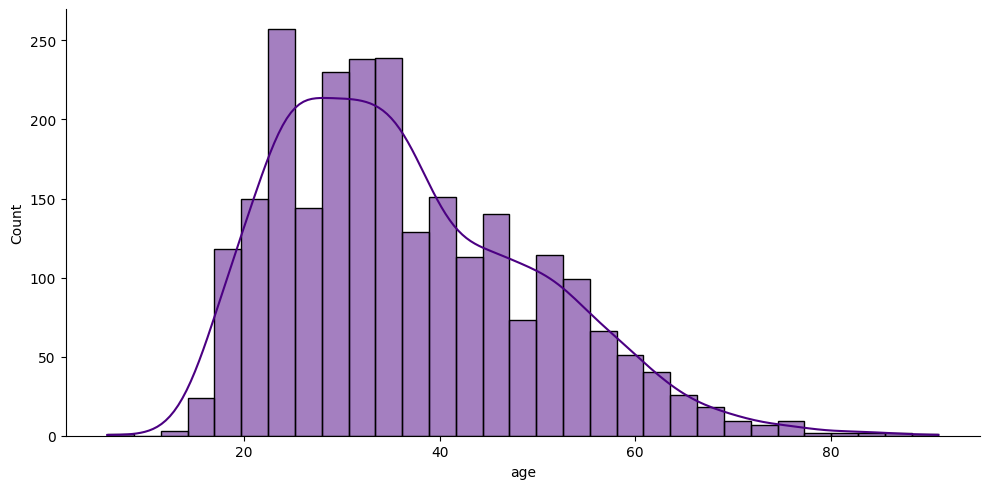

In [27]:
sns.displot(data=df_fatalities.sort_values(by='age', ascending=True),
            x='age',
            kde=True,
            color='indigo',
            aspect=2)

Create a seperate KDE plot for each race. Is there a difference between the distributions?

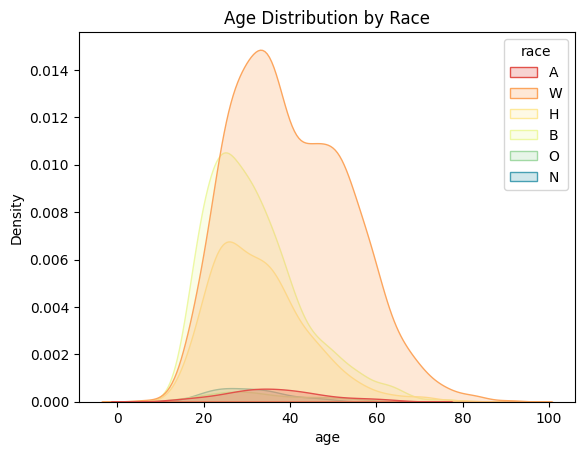

In [36]:
sns.kdeplot(data=df_fatalities,
            x='age',
            hue='race',
            fill=True,
            palette='Spectral')

plt.title('Age Distribution by Race')
plt.show()

# Race of People Killed

Create a chart that shows the total number of people killed by race.

In [42]:
fatal_counts_by_race = df_fatalities['race'].value_counts()
print(fatal_counts_by_race)

race
W    1201
B     618
H     423
A      39
N      31
O      28
Name: count, dtype: int64


In [50]:
fatal_counts_by_race_bar = px.bar(df_fatalities,
             x=fatal_counts_by_race.index,
             y=fatal_counts_by_race.values,
             color=fatal_counts_by_race.index,
             title='Count of Fatalities by Race')
fatal_counts_by_race_bar.update_traces(width=0.5)
fatal_counts_by_race_bar.update_layout(
    xaxis_title='Race',
    yaxis_title='Count',
    legend_title='Race',
    bargap=0.2
)

fatal_counts_by_race_bar.show()

# Mental Illness and Police Killings

What percentage of people killed by police have been diagnosed with a mental illness?

In [53]:
fatal_counts_by_mentals = df_fatalities['signs_of_mental_illness'].value_counts()

fatal_counts_by_mentals_pie = px.pie(values=fatal_counts_by_mentals.values,
             names=fatal_counts_by_mentals.index,
             hole=0.4, title='Percentage of People Killed by Mental Illness')
fatal_counts_by_mentals_pie.show()

race
W    1201
B     618
H     423
A      39
N      31
O      28
Name: count, dtype: int64


# In Which Cities Do the Most Police Killings Take Place?

Create a chart ranking the top 10 cities with the most police killings. Which cities are the most dangerous?  

In [57]:
fatal_counts_by_city_top10 = df_fatalities['city'].value_counts()[:10]

fatal_counts_by_city_top10_pie = px.pie(values=fatal_counts_by_city_top10.values,
             names=fatal_counts_by_city_top10.index,
             hole=0.4, title='Percentage of People Killed by City (Top 10)')
fatal_counts_by_city_top10_pie.show()

city
Los Angeles      39
Phoenix          31
Houston          27
Chicago          25
Las Vegas        21
                 ..
Mamou             1
Lacey             1
Crescent City     1
Newton Grove      1
Uniontown         1
Name: count, Length: 1417, dtype: int64


# Rate of Death by Race

Find the share of each race in the top 10 cities. Contrast this with the top 10 cities of police killings to work out the rate at which people are killed by race for each city.

In [71]:
top10_cities_by_fatal = df_fatalities['city'].value_counts().head(10).index

fatal_counts_by_city_race = df_fatalities.groupby(['city', 'race'])['id'].count().reset_index()

fatal_counts_by_city_race_top10 = fatal_counts_by_city_race[fatal_counts_by_city_race['city'].isin(top10_cities_by_fatal)]

fatal_counts_by_city_race_bar_top10 = px.bar(fatal_counts_by_city_race_top10,
             x='city',
             y='id',
             color='race',
             title='Count of Fatalities by City and Race')
fatal_counts_by_city_race_bar_top10.update_traces(width=0.5)
fatal_counts_by_city_race_bar_top10.update_layout(
    xaxis_title='City',
    yaxis_title='Count of Fatalities',
    legend_title='Race',
    bargap=0.2
)

fatal_counts_by_city_race_bar_top10.update_layout(xaxis={'categoryorder': 'total descending'})

fatal_counts_by_city_race_bar_top10.show()

# Create a Choropleth Map of Police Killings by US State

Which states are the most dangerous? Compare your map with your previous chart. Are these the same states with high degrees of poverty?

In [95]:
fatal_counts_by_state = df_fatalities['state'].value_counts().reset_index()
fatal_counts_by_state.columns = ['State', 'Count']

fatal_counts_by_state_chor = px.choropleth(data_frame=fatal_counts_by_state,
                    locations='State',
                    locationmode='USA-states',
                    color='Count',
                    color_continuous_scale='orrd',
                    hover_name='Count',
                    title='Fatalities of Police Killings by State')
fatal_counts_by_state_chor.update_layout(geo_scope='usa')
fatal_counts_by_state_chor.show()

# Number of Police Killings Over Time

Analyse the Number of Police Killings over Time. Is there a trend in the data?

In [92]:
df_fatalities['period'] = pd.to_datetime(df_fatalities['date']).dt.strftime('%Y/%m')

fatal_counts_by_period = df_fatalities['period'].value_counts().sort_index().reset_index()
fatal_counts_by_period.columns = ['Period', 'Count']
fatal_counts_by_period_line = px.line(fatal_counts_by_period,
             x='Period',
             y='Count',
             title='Number of Police Killings Over Time')
fatal_counts_by_period_line.show()

# Epilogue

Now that you have analysed the data yourself, read [The Washington Post's analysis here](https://www.washingtonpost.com/graphics/investigations/police-shootings-database/).